# Prepare & Sample Gold Standard Dataset

## Prerequisites

In [59]:
%pip install matplotlib pandas presidio_analyzer presidio_anonymizer


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [60]:
import pandas as pd
import matplotlib as plt
import numpy as np
import re
import json

from presidio_analyzer import AnalyzerEngine, BatchAnalyzerEngine, RecognizerResult, DictAnalyzerResult
from presidio_anonymizer import AnonymizerEngine, BatchAnonymizerEngine
from presidio_anonymizer.entities import EngineResult

In [61]:
RANDOM_STATE = 42

## Set up taxonomy regex - query Athena

In [62]:
# Using (?i) for case-insensitivity. 
# Using \\b for word boundaries (so 'asb' doesn't match 'wasburn')

category_regex_dict = {
    # 1. Safety & Risk
    # Includes: Domestic abuse, Fire, Exploitation, Gangs, ASB, Child risk, Criminal, Violence, Gas Capped, Medically unsuitable
    "cat_safety_risk": r"(domestic\s+(abuse|violence)|fire\s+(risk|hazard|safety)|exploit(?:ation|ed)|cuckooing|gang(?:s)?\b|\basb\b|anti[-\s]?social|child(?:ren)?\s+at\s+risk|criminal|violenc[e]|violent|gas\s+capped|unsuitable\s+(home|property))",

    # 2. Mobility
    # Includes: Physical disability, Temporary mobility, General mobility issues
    "cat_mobility": r"(mobility|wheelchair|walking\s+(stick|frame)|crutches|bedbound|housebound|paralys(?:ed|zed)|physical(?:ly)?\s+(?:disab|impair)|amputee)",

    # 3. Life Events
    # Includes: Identity, Refugee, Veteran, Trauma, Bereavement, Children removed, Institution, Rehousing, Prison, Homelessness
    "cat_life_events": r"(transgender|non[- ]binary|refugee|asylum\s+seeker|veteran|armed\s+forces|trauma|bereave(?:ment|d)|pass(?:ed)?\s+away|\bdied\b|children\s+removed|decant|rehous|prison|jail|homeless|sleeping\s+rough|temporary\s+accommodation)",

    # 4. Housing Conditions
    # Includes: Basic needs, Disrepair, Infestation, Dangerous animals, Self-neglect, Damp/Mould, Overcrowding
    "cat_housing_conditions": r"(disrepair|infest(?:ation|ed)|mice|rats|cockroaches|bed\s+bugs|dangerous\s+(dog|animal)|self[-\s]?neglect|hoard(?:ing|er)|damp|mou?ld|overcrowd(?:ing|ed)|no\s+(heating|water|electricity|gas))",

    # 5. Health
    # Includes: Terminal, Care setting (medical), Mental capacity, Neurodiversity, Cognitive, Reproductive, Young children, Respiratory, Mental Health, Isolation, Poor health, EHCP
    "cat_health": r"(terminal(?:ly)?|end\s+of\s+life|mental\s+capacity|autis(?:m|tic)|adhd|learning\s+disab|dementia|alzheimer|cognitiv|pregnan|maternity|asthma|copd|respiratory|breath(?:ing)?|mental\s+health|depression|anxiety|suicid|isolat(?:ed|ion)|ehcp|poor\s+health)",

    # 6. Financial
    # Includes: Income status, Cost of living, Financial affairs/team
    "cat_financial": r"(financial\s+(?:hardship|difficult)|\barrears\b|\bdebt\b|food\s+bank|cost\s+of\s+living|universal\s+credit|\buc\b|benefits|income\s+support)",

    # 7. Disability (Sensory Focus)
    # Includes: Hearing, Visual, Speech impairments
    "cat_disability": r"(\bblind\b|\bdeaf\b|visually\s+impaired|hearing\s+impaired|hard\s+of\s+hearing|sensory)",

    # 8. Communication Needs
    # Includes: Digital exclusion, Language/Literacy barriers
    "cat_communication": r"(digital(?:ly)?\s+exclu|no\s+internet|no\s+smartphone|interpreter|translat(?:or|ion)|illiterat|cannot\s+read|language\s+barrier|esol)",

    # 9. Care
    # Includes: Care leaver/experienced, Looked after, Social care client, Caring responsibility
    "cat_care": r"(care\s+leaver|care\s+experienced|looked\s+after\s+child|\blac\b|social\s+(?:care|worker)|carer|caring\s+responsibilit|nursing\s+home|care\s+home)",

    # 10. Addiction
    # Includes: Gambling, Substance misuse
    "cat_addiction": r"(gambling|betting|substance\s+(?:misuse|abuse)|\bdrug\b|\balcohol\b|addict(?:ion|ed))",

    # 11. Adaptation
    # Includes: Requires adapted property, specific adaptations
    "cat_adaptation": r"(adapt(?:ed|ation)|wet\s+room|stairlift|ramp|hoist|grab\s+rail(?:s)?)"
}

In [63]:
select_lines = [
    "n.*"
]

# Loop through our new 11 categories
for category, pattern in category_regex_dict.items():
    # Athena needs backslashes safely escaped in the SQL string
    athena_safe_pattern = pattern.replace('\\', '\\\\')
    sql_line = f"regexp_like(n.note_content, '{athena_safe_pattern}') AS {category}"
    select_lines.append(sql_line)

sql = f'SELECT {",\n    ".join(select_lines)}\n\
    FROM "housing-refined-zone".additional_needs_notes_reshaped n \n\
    WHERE flag_note_date_parse_failed = FALSE\n\
        AND flag_no_matching_target = FALSE\n\
        AND flag_is_organisation = FALSE\n\
        AND flag_inactive = FALSE'
print(sql)

SELECT n.*,
    regexp_like(n.note_content, '(domestic\\s+(abuse|violence)|fire\\s+(risk|hazard|safety)|exploit(?:ation|ed)|cuckooing|gang(?:s)?\\b|\\basb\\b|anti[-\\s]?social|child(?:ren)?\\s+at\\s+risk|criminal|violenc[e]|violent|gas\\s+capped|unsuitable\\s+(home|property))') AS cat_safety_risk,
    regexp_like(n.note_content, '(mobility|wheelchair|walking\\s+(stick|frame)|crutches|bedbound|housebound|paralys(?:ed|zed)|physical(?:ly)?\\s+(?:disab|impair)|amputee)') AS cat_mobility,
    regexp_like(n.note_content, '(transgender|non[- ]binary|refugee|asylum\\s+seeker|veteran|armed\\s+forces|trauma|bereave(?:ment|d)|pass(?:ed)?\\s+away|\\bdied\\b|children\\s+removed|decant|rehous|prison|jail|homeless|sleeping\\s+rough|temporary\\s+accommodation)') AS cat_life_events,
    regexp_like(n.note_content, '(disrepair|infest(?:ation|ed)|mice|rats|cockroaches|bed\\s+bugs|dangerous\\s+(dog|animal)|self[-\\s]?neglect|hoard(?:ing|er)|damp|mou?ld|overcrowd(?:ing|ed)|no\\s+(heating|water|electricity|

## Import df, calculate metrics

In [64]:
cols = ["note_id","cat_safety_risk","cat_mobility","cat_life_events","cat_housing_conditions","cat_health","cat_financial","cat_disability","cat_communication","cat_care","cat_addiction","cat_adaptation"]
df = pd.read_csv('./data/input/regex_results.csv', usecols=cols)

df

,note_id,cat_safety_risk,cat_mobility,cat_life_events,cat_housing_conditions,cat_health,cat_financial,cat_disability,cat_communication,cat_care,cat_addiction,cat_adaptation
0,3c0b312c-dbac-8b9e-7aea-f498c148d6f0,False,False,False,False,False,False,False,False,False,False,False
1,4471b4f3-2c40-de3d-9f71-4a94bf276ed5,False,False,False,False,False,False,False,False,False,False,False
2,47794849-32e7-3f12-1e2d-1d2f9dfd0adb,False,False,False,False,False,False,False,False,False,False,False
3,677f5a9c-585d-78e7-4560-f5f43b4a449b,False,False,False,False,False,False,False,False,False,False,False
4,79c829fd-733b-5b63-de88-36e35ed3c2e3,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
731177,70ddb3a9-3ce6-df29-820e-c82b7297ffa7,False,False,False,False,False,False,False,False,False,False,False
731178,a0db9fde-8c0e-218c-37df-e88d75137c4a,False,False,False,False,False,False,False,False,False,False,False
731179,a45124ee-a28f-201c-bee3-6ad6ff65b5b4,False,False,False,False,False,False,False,False,False,False,False
731180,de00e635-2184-9401-fa80-fd7d43e80624,False,False,False,False,False,False,False,False,False,False,False


In [65]:
label_freqs = df.drop(columns='note_id')\
                .sum(axis=0)\
                .sort_values(ascending=True)
label_freqs

cat_disability               17
cat_addiction                48
cat_care                   1186
cat_adaptation             1298
cat_mobility               1593
cat_financial              1902
cat_safety_risk            1931
cat_health                 3520
cat_communication          4621
cat_housing_conditions     8805
cat_life_events           13432
dtype: int64

<Axes: title={'center': 'Count of Notes by Category'}>

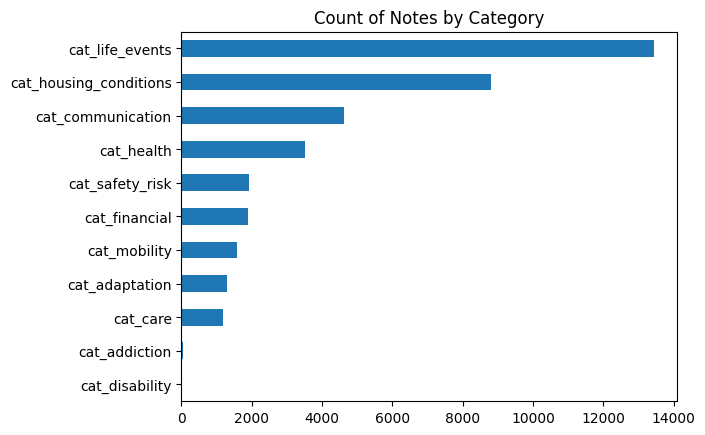

In [66]:

label_freqs.plot.barh(title='Count of Notes by Category')

In [67]:
def calculate_ml_imbalance_metrics(df):
    """
    Calculates IRLbl, MeanIR, MaxIR, and CVIR for multi-label data.
    """
    # 1. Calculate IRLbl (Imbalance Ratio per Label)
    # Ratio between the majority label frequency and each label's frequency
    max_freq = df.max()
    irlbl = max_freq / df
    
    #23. MeanIR (Mean Imbalance Ratio)
    meanir = irlbl.mean()
    
    # 3. MaxIR (Maximum Imbalance Ratio)
    maxir = irlbl.max()
    
    # 5. CVIR (Coefficient of Variation of IRLbl)
    # Measures the variation/similarity of imbalance levels across labels
    cvir = irlbl.std() / irlbl.mean()
    
    return {
        "IRLbl": irlbl,
        "MeanIR": meanir,
        "MaxIR": maxir,
        "CVIR": cvir
    }

metrics = calculate_ml_imbalance_metrics(label_freqs)

print(f"IRLbl: {metrics['IRLbl'].values}")
print(f"MeanIR: {metrics['MeanIR']:.2f}")
print(f"MaxIR: {metrics['MaxIR']:.2f}")
print(f"CVIR: {metrics['CVIR']:.2f}")

IRLbl: [790.11764706 279.83333333  11.32546374  10.34822804   8.43188952
   7.06203996   6.95598136   3.81590909   2.90673014   1.52549688
   1.        ]
MeanIR: 102.12
MaxIR: 790.12
CVIR: 2.38


## Sample data (n=2000)

In [68]:
# ML-RUS (Random Undersampling)

sampled_data = []

# Get all from lowest categories  (disability, addiction - 17 + 48 = 65)
sampled_data.append(df[df['cat_disability'] == True])
sampled_data.append(df[df['cat_addiction'] == True])

# Grab 150 each from the remaining categories (150 * 9 = 1350)
categories_to_sample = [
    'cat_safety_risk', 'cat_mobility', 'cat_life_events', 
    'cat_housing_conditions', 'cat_health', 'cat_financial', 
    'cat_communication', 'cat_care', 'cat_adaptation'
]
for cat in categories_to_sample:
    cat_sample = df[df[cat] == True].sample(n=150, random_state=RANDOM_STATE)
    sampled_data.append(cat_sample)

In [69]:
# Get total flags per row. Find ones with 0 and sample remaining count (2000 - 1350 - 65 = 585)
df['total_flags'] = df.drop(columns='note_id').sum(axis=1)
df['unflagged'] = df['total_flags'] == 0
df.drop(columns=['total_flags'], inplace=True)

unflagged_records_sample = df[df['unflagged'] == True].sample(n=600, random_state=RANDOM_STATE)
unflagged_records_sample

,note_id,cat_safety_risk,cat_mobility,cat_life_events,cat_housing_conditions,cat_health,cat_financial,cat_disability,cat_communication,cat_care,cat_addiction,cat_adaptation,unflagged
367448,f754336f-0090-4578-9985-a631afb8994e,False,False,False,False,False,False,False,False,False,False,False,True
117253,a1bc5f3f-a832-306e-88d5-b49556b37b93,False,False,False,False,False,False,False,False,False,False,False,True
461126,89fba8a2-bc13-411c-b3b3-ce4490c94eef,False,False,False,False,False,False,False,False,False,False,False,True
580479,288d8931-b940-d328-2956-beca35367527,False,False,False,False,False,False,False,False,False,False,False,True
104741,90ec3965-1975-ee34-d0ac-9bc557bbc8e2,False,False,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48078,a012334e-1f6b-aa75-d9cc-ed030b213605,False,False,False,False,False,False,False,False,False,False,False,True
483956,64cae06b-cb3f-413c-bc12-7f7154827bf3,False,False,False,False,False,False,False,False,False,False,False,True
605747,5799fc21-7da7-3c99-948e-f71636c24c46,False,False,False,False,False,False,False,False,False,False,False,True
243544,c029e611-2749-061d-7330-584b7cd4eac4,False,False,False,False,False,False,False,False,False,False,False,True


In [70]:
sampled_data.append(unflagged_records_sample)

# Combine & drop duplicates
final_sample = pd.concat(sampled_data)
final_sample = final_sample.drop_duplicates(subset=['note_id'])
final_sample.fillna(False, inplace=True)
final_sample

,note_id,cat_safety_risk,cat_mobility,cat_life_events,cat_housing_conditions,cat_health,cat_financial,cat_disability,cat_communication,cat_care,cat_addiction,cat_adaptation,unflagged
16028,351b501f-f877-7b51-1b07-f065d07f0147,False,False,False,False,False,False,True,False,False,False,False,False
31465,0cf1dcef-63cd-4a0f-bb84-6f316de60a5c,False,False,False,False,False,False,True,False,False,False,False,False
51881,f96a9bbe-4d1c-2efa-c2e4-1e3551f80fee,False,False,False,False,False,False,True,False,True,False,False,False
134837,4e5a965a-0e88-490a-807e-ffb2adc0f69e,False,False,False,False,False,False,True,False,False,False,False,False
136128,b0ba31aa-8484-415c-9f5b-20c9bd1be3c2,False,False,False,True,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48078,a012334e-1f6b-aa75-d9cc-ed030b213605,False,False,False,False,False,False,False,False,False,False,False,True
483956,64cae06b-cb3f-413c-bc12-7f7154827bf3,False,False,False,False,False,False,False,False,False,False,False,True
605747,5799fc21-7da7-3c99-948e-f71636c24c46,False,False,False,False,False,False,False,False,False,False,False,True
243544,c029e611-2749-061d-7330-584b7cd4eac4,False,False,False,False,False,False,False,False,False,False,False,True


In [71]:
final_sample.drop(columns=['note_id']).sum(axis=0)

cat_safety_risk           161
cat_mobility              178
cat_life_events           264
cat_housing_conditions    232
cat_health                184
cat_financial             161
cat_disability             17
cat_communication         185
cat_care                  163
cat_addiction              48
cat_adaptation            172
unflagged                 598
dtype: object

## PII Redaction

In [72]:
# Rejoin with content
note_lookup = pd.read_csv('data/input/regex_results.csv', usecols=['note_id', 'note_content', 'note_category'])

# Add the note category as a prefix to the note content
note_lookup['note_content'] = "[Category: " + note_lookup['note_category'].fillna('Unknown').astype(str) + "] " + note_lookup['note_content'].astype(str)

unredacted_df = final_sample.merge(note_lookup, on='note_id', how='left')
unredacted_df.drop_duplicates(subset=['note_id'], keep='first', inplace=True)

In [73]:
# DataFrame to dict
df_dict = unredacted_df.to_dict(orient="list")

In [74]:
analyzer = AnalyzerEngine()
batch_analyzer = BatchAnalyzerEngine(analyzer_engine=analyzer)
batch_anonymizer = BatchAnonymizerEngine()

In [75]:
keys_to_skip = ["note_id","note_category","cat_safety_risk","cat_mobility","cat_life_events","cat_housing_conditions","cat_health","cat_financial","cat_disability","cat_communication","cat_care","cat_addiction","cat_adaptation"]
# Skip all keys except 'note_content'. note_content is the only one with sensitive information.

analyzer_results = batch_analyzer.analyze_dict(df_dict, language="en")
analyzer_results = list(analyzer_results)
analyzer_results

[DictAnalyzerResult(key='note_id', value=['351b501f-f877-7b51-1b07-f065d07f0147', '0cf1dcef-63cd-4a0f-bb84-6f316de60a5c', 'f96a9bbe-4d1c-2efa-c2e4-1e3551f80fee', '4e5a965a-0e88-490a-807e-ffb2adc0f69e', 'b0ba31aa-8484-415c-9f5b-20c9bd1be3c2', 'a9af0571-9ce7-4b78-a5af-7d8b7b38d163', 'afb32651-bcb2-42fe-9461-a8ee0a6f639a', '9bc932da-6e39-4e79-bfd3-c9f43f978891', '6aa26b8a-e835-4b86-8c09-0c3d1331fc04', 'd5967e12-570d-40ee-8b23-feed991dface', 'b0ffb010-37f8-42b2-9901-839de6069d25', 'b2c47154-3fca-40f8-a750-2d396c120189', '0fc0d2f8-2aa4-46ed-8de0-82a3f2a709a1', 'e18c0a1d-5e58-47b9-968d-adb6f244f57e', '3a2f5423-f9bc-4578-befa-bd92be722a23', 'cfc57bf5-def8-c054-9153-34812d26fdde', '3993b6d1-db31-f25b-226f-43a34098e6e4', 'ee0e5e31-5b60-db3e-08d4-0f17e9388368', '32f8ee05-6299-ec3a-d4fb-2ab01b92f5e0', '985620eb-c566-64b6-243c-f94f7e589865', 'bd8ecaaa-e59b-9789-8844-c4ef8b61d7ec', '98b4d95d-1ae9-9acc-bcc6-addd63ce81e2', '75c3f55a-0e86-93d8-2778-30c31e45ff4c', '59445bdc-3d65-9a7c-0056-3b4411f2cd5e'

In [76]:
anonymizer_results = batch_anonymizer.anonymize_dict(analyzer_results)
output_df = pd.DataFrame(anonymizer_results)
output_df

,note_id,cat_safety_risk,cat_mobility,cat_life_events,cat_housing_conditions,cat_health,cat_financial,cat_disability,cat_communication,cat_care,cat_addiction,cat_adaptation,unflagged,note_content,note_category
0,351b501f-<US_DRIVER_LICENSE>-7b51-1b07-f065d07...,False,False,False,False,False,False,True,False,False,False,False,False,[Category: Tenure management] Call Summary; Ca...,Tenure management
1,0cf1dcef-63cd-4a0f-bb84-6f316de60a5c,False,False,False,False,False,False,True,False,False,False,False,False,[Category: Tenure management] ADDITIONAL NOTE ...,Tenure management
2,f96a9bbe-4d1c-2efa-c2e4-1e3551f80fee,False,False,False,False,False,False,True,False,True,False,False,False,[Category: Tenure management] Dear Marcia\n\nD...,Tenure management
3,4e5a965a-0e88-490a-807e-ffb2adc0f69e,False,False,False,False,False,False,True,False,False,False,False,False,[Category: estateManagement] PSED Consideratio...,estateManagement
4,b0ba31aa-8484-415c-9f5b-20c9bd1be3c2,False,False,False,True,False,False,True,False,False,False,False,False,[Category: tenureManagement] reply from tnt re...,tenureManagement
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996,a012334e-1f6b-aa75-d9cc-ed030b213605,False,False,False,False,False,False,False,False,False,False,False,True,[Category: Tenure management] Direct Offer: As...,Tenure management
1997,64cae06b-cb3f-413c-bc12-7f7154827bf3,False,False,False,False,False,False,False,False,False,False,False,True,[Category: tenureManagement] New Let Introduct...,tenureManagement
1998,5799fc21-7da7-3c99-948e-f71636c24c46,False,False,False,False,False,False,False,False,False,False,False,True,[Category: Tenancy Management] Call Summary; C...,Tenancy Management
1999,c029e611-2749-061d-7330-584b7cd4eac4,False,False,False,False,False,False,False,False,False,False,False,True,[Category: Tenancy Management] Client has reci...,Tenancy Management


## Export

## CSV

In [77]:
output_df.to_csv('data/output/balanced_sample.csv', index=False)

## Build JSON (label studio)

In [78]:
label_mapping = {
    "cat_safety_risk": "Safety & Risk",
    "cat_mobility": "Mobility",
    "cat_life_events": "Life Events",
    "cat_housing_conditions": "Housing Conditions",
    "cat_health": "Health",
    "cat_financial": "Financial",
    "cat_disability": "Disability (Sensory)",
    "cat_communication": "Communication Needs",
    "cat_care": "Care",
    "cat_addiction": "Addiction",
    "cat_adaptation": "Adaptation"
}

label_studio_tasks = []

for index, row in output_df.iterrows():
    # Loop through each row and build the JSON structure
    text = str(row['note_content'])
    note_id = str(row['note_id'])
    identified_labels = []
    
    for cat_key, regex_pattern in category_regex_dict.items():
        if row.get(cat_key) == False:
            continue  # Skip if athena didn't flag this category for the note
        
        label_name_parsed = label_mapping[cat_key]
        for match in re.finditer(regex_pattern, text): # finditer finds the specific chars where the regex matches
            identified_labels.append({
                "from_name": "need_labels", 
                "to_name": "text",
                "type": "labels",
                "value": {
                    "start": match.start(),
                    "end": match.end(),
                    "text": match.group(),
                    "labels": [label_name_parsed]
                }
            })
    
    # Construct the final JSON payload (label studio structure - docs)
    task = {
        "data": {
            "note_content": text,
            "id": note_id
        },
        "predictions": [{
            "model_version": "athena_regex_pre_annotated",
            "score": 1.0,
            "result": identified_labels
        }]
    }
        
    label_studio_tasks.append(task)

In [79]:
with open("data/output/label_studio_pre_annotated.json", "w") as f:
    json.dump(label_studio_tasks, f, indent=2)

len(label_studio_tasks)

2001